In [38]:
import pandas as pd 
import numpy as np 


In [39]:
df=pd.read_csv("Student Performance Factors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [41]:

df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [42]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

In [43]:
df.isnull().sum()


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [44]:
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


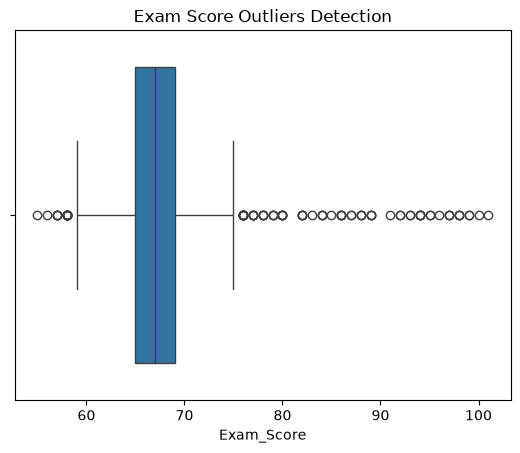

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df['Exam_Score'])
plt.title('Exam Score Outliers Detection')
plt.show()

In [46]:

df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100

In [47]:
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,100.00


In [48]:
df['Passed'] = (df['Exam_Score'] >= 65).astype(int)
df.drop(columns=['Exam_Score'], inplace=True)
df['Passed'].value_counts()

Passed
1    5155
0    1452
Name: count, dtype: int64

In [49]:
from sklearn.preprocessing import LabelEncoder
categorical_cols=df.select_dtypes(include=['object']).columns
le=LabelEncoder()
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])
df.head()    


C:\Users\shaza\AppData\Local\Temp\ipykernel_9616\3788872446.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=df.select_dtypes(include=['object']).columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Passed
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,1
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,0
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,1
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,1
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,1


C:\Users\shaza\AppData\Local\Temp\ipykernel_9616\227980009.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Passed', y='Hours_Studied', data=df, palette='Set2')


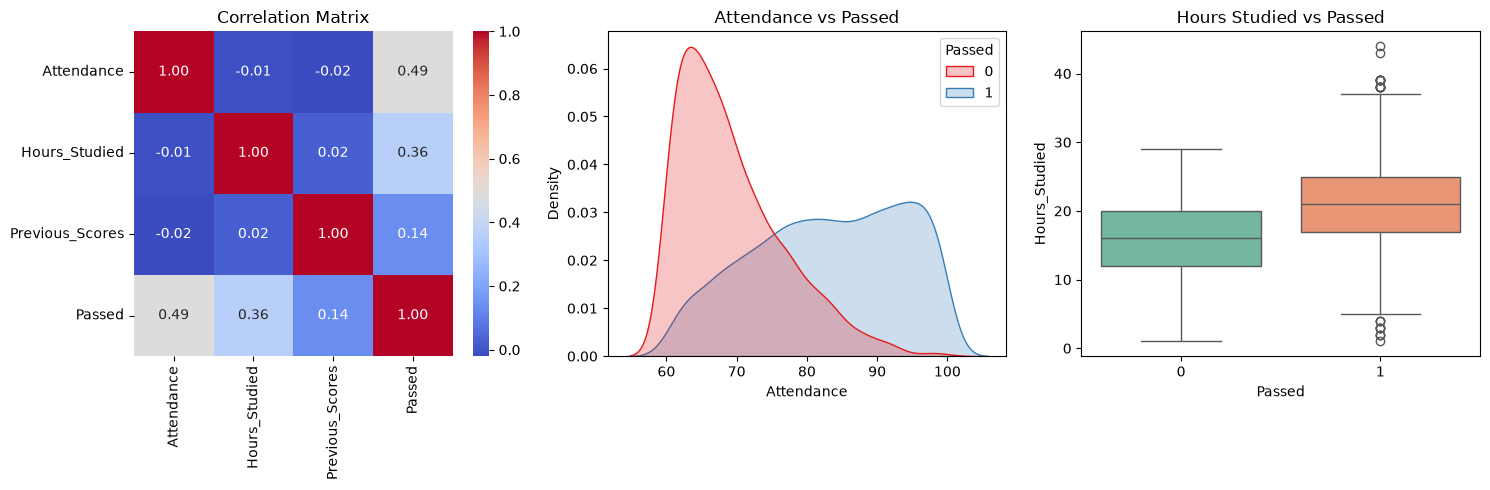

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 1. خريطة الارتباط بين أهم المتغيرات والنجاح
plt.subplot(1, 3, 1)
cols = ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Passed']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

# 2. تأثير الحضور على النجاح والرسوب
plt.subplot(1, 3, 2)
sns.kdeplot(data=df, x='Attendance', hue='Passed', common_norm=False, palette='Set1', fill=True)
plt.title('Attendance vs Passed')

# 3. ساعات المذاكرة مقارنة بالنجاح والرسوب
plt.subplot(1, 3, 3)
sns.boxplot(x='Passed', y='Hours_Studied', data=df, palette='Set2')
plt.title('Hours Studied vs Passed')

plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split

# تحديد المتغيرات المستقلة والهدف
X = df.drop(columns=['Passed'])  # استبدل باسم عمود الهدف عندك
y = df['Passed']

# تقسيم البيانات لـ 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    rec_0 = recall_score(y_test, preds, pos_label=0)
    f1_0 = f1_score(y_test, preds, pos_label=0)     
    
    results.append({
        'Model': name,
        'Accuracy': f"{acc*100:.2f}%",
        'Recall (Failed Class)': f"{rec_0*100:.2f}%",
        'F1-Score (Failed Class)': f"{f1_0*100:.2f}%"
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Recall (Failed Class),F1-Score (Failed Class)
0,Logistic Regression,89.33%,91.07%,78.99%
1,Decision Tree,86.08%,65.98%,67.61%
2,Random Forest,90.39%,79.73%,78.51%


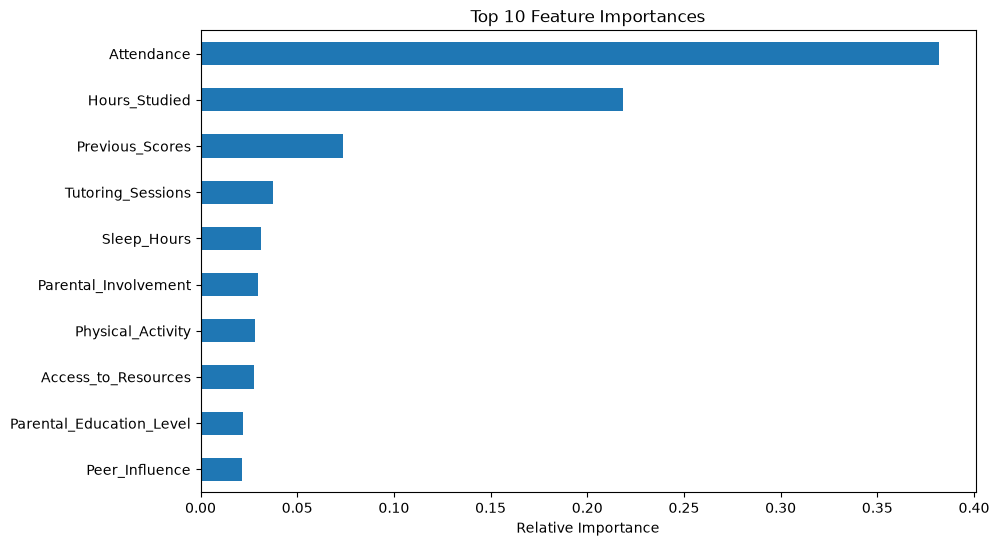

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()

In [54]:
import pandas as pd

# 1. تجهيز بيانات طالب جديد للتجربة (عينة من X_test)
sample_student = X_test.iloc[[0]] 

# 2. التنبؤ باستخدام موديل Logistic Regression
log_model = models['Logistic Regression']
prediction = log_model.predict(sample_student)[0]
probability = log_model.predict_proba(sample_student)[0][1]

# 3. عرض النتيجة بشكل واضح
status = "Passed (ناجح) 🎓" if prediction == 1 else "Failed (راسب) ⚠️"


print(f"Prediction Result: {status}")
print(f"Probability of Passing: {probability * 100:.2f}%")


Prediction Result: Failed (راسب) ⚠️
Probability of Passing: 9.63%


In [55]:
import joblib

# حفظ الموديل المعتمد
log_model = models['Logistic Regression']
joblib.dump(log_model, 'student_model.pkl')

# حفظ قائمة أسماء الأعمدة للتأكد من الترتيب أثناء التنبؤ
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("✅ تم حفظ الموديل بنجاح!")

✅ تم حفظ الموديل بنجاح!
